In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [34]:
df = pd.read_csv('../data/data-week-3.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index) #object only is selected because it we are dealing with string in the below code

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [36]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [37]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
# totalcharges currently string need to convert to numeric
tc = pd.to_numeric(df.totalcharges, errors='coerce') #suppress error for unparseable string

In [39]:
tc.isnull().sum()

np.int64(11)

In [40]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


# These are customers who just joined - their tenure is small and they haven't been billed yet, so their total charges are not available. For them we simply fill the missing values with zero:



In [41]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

# Encoding the target variable

In [42]:
df.churn = (df.churn == 'yes').astype(int)

In [43]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [44]:
# The remaining 80% we call the full train set. 
# Then we split it again into train and validation:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [45]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [46]:
# Resetting the index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [47]:
#isolating churn target
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [48]:
# delete target from datframe sets
del df_train['churn']
del df_val['churn']
del df_test['churn']

# EDA

In [49]:
# Missing values
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [50]:
df_full_train.churn.value_counts(normalize=True)

churn
0    1.0
Name: proportion, dtype: float64

In [51]:
df_full_train.churn.mean()

np.float64(0.0)

Numerical and categorical variables

In [52]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']
# feature such as seniorcitizen is encoded as 0 or 1. However, it is a object type i.e categorical column
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]


In [53]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

# Feature importance: Churn rate and risk ratio
Feature importance analysis is a part of EDA: we want to identify which features affect our target variable. In this unit we do it for categorical variables by comparing the churn rate of each group with the global churn rate, first as a difference and then as a ratio.




In [54]:
# Churn rate per group exploring each feature one by one
global_churn = df_full_train.churn.mean()
print(f"Gloabl churn {global_churn}")

#gender feature churn
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
print(f"churn_female: {churn_female}")
print(f"churn_male: {churn_male}")

churn_female_diff = global_churn - churn_female
churn_male_diff = global_churn - churn_male

print(f"churn_female_diff: {churn_female_diff}")
print(f"churn_male_diff: {churn_male_diff}")

Gloabl churn 0.0
churn_female: nan
churn_male: nan
churn_female_diff: nan
churn_male_diff: nan


from note, 
The global churn rate is 0.27, women churn at 0.2768 and men at 0.2632. The differences are tiny. We compute them explicitly as the global rate minus the group rate:


Both differences are close to zero, so gender is probably not an important feature: knowing whether a customer is a man or a woman tells us almost nothing about churn.

Now let's look at a more promising variable - whether the customer has a partner. First, how many customers are there in each group?


Both differences are close to zero, so gender is probably not an important feature: knowing whether a customer is a man or a woman tells us almost nothing about churn.

Now let's look at a more promising variable - whether the customer has a partner. First, how many customers are there in each group?



In [55]:
df_full_train.partner.value_counts()

partner
No     2932
Yes    2702
Name: count, dtype: int64

In [56]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
print(f"churn_partner {churn_partner}")
print(f"churn_no_partner {churn_no_partner}")


churn_partner nan
churn_no_partner nan


from note:

global_churn - churn_partner     =  0.06493474245795922
global_churn - churn_no_partner  = -0.05984095297455855

With this definition - global rate minus group rate - a positive difference means the group churns less than average, and a negative difference means it churns more. The larger the absolute difference, the more important the variable.



# Doing it for every variable with groupby


SELECT gender, AVG(churn), AVG(churn) - global_churn AS diff, AVG(churn) / global_churn AS risk
FROM data
GROUP BY gender;

In [57]:
#In Pandas
from IPython.display import display

for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
Female,0.0,2796,0.0,NaN
Male,0.0,2838,0.0,NaN




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.0,4722,0.0,NaN
1,0.0,912,0.0,NaN




partner


...

,mean,count,diff,risk
contract,,,,
Month-to-month,0.0,3104,0.0,NaN
One year,0.0,1186,0.0,NaN
Two year,0.0,1344,0.0,NaN




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
No,0.0,2313,0.0,NaN
Yes,0.0,3321,0.0,NaN




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
Bank transfer (automatic),0.0,1219,0.0,NaN
Credit card (automatic),0.0,1217,0.0,NaN
Electronic check,0.0,1893,0.0,NaN
Mailed check,0.0,1305,0.0,NaN


# Risk Ratio
The difference is expressed in absolute terms. The same idea can be expressed in relative terms - as a ratio between the group churn rate and the global churn rate:

![Risk Ratio](../../images/05-risk-03-difference-vs-risk-ratio-imagegen-pilot.jpg)

churn_no_partner / global_churn = 1.2216593879412643   
churn_partner / global_churn = 0.7594724924338315

This is the risk ratio. It is easy to read:

risk = 1 means the group is as likely to churn as everyone else
risk > 1 means the group is more likely to churn
risk < 1 means the group is less likely to churn
Customers without a partner have a risk of 1.22 - they churn 22% more often than the average customer. Customers with a partner have a risk of 0.76 - they churn about 24% less often.



# Feature importance: Mutual information


The churn rate and risk ratio from the previous unit tell us which groups within one variable churn more, but they don't let us compare whole variables with each other. Mutual information fixes that: it is a single number per variable that measures how important it is.

Mutual information is a concept from information theory. It tells us how much we can learn about one variable if we know the value of another.

Applied to our project: how much do we learn about churn if we know the customer's contract type? If knowing a feature always gives us useful information about churn, the mutual information between them is high and the feature is important. If the feature tells us nothing, the mutual information is 0.

In this project we use mutual information to measure the importance of categorical variables.

![Mutual-Information](../../images/06-mutual-info-01-mutual-information-wikipedia-imagegen-pilot.jpg)


In [58]:
from sklearn.metrics import mutual_info_score

#applying to all caegrical variable

def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

gender              0.0
seniorcitizen       0.0
partner             0.0
dependents          0.0
phoneservice        0.0
multiplelines       0.0
internetservice     0.0
onlinesecurity      0.0
onlinebackup        0.0
deviceprotection    0.0
techsupport         0.0
streamingtv         0.0
streamingmovies     0.0
contract            0.0
paperlessbilling    0.0
paymentmethod       0.0
dtype: float64

#In note  
contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

# Notes on Mutual Information

Mutual information is a concept from information theory, which measures how much we can learn about one variable if we know the value of another. In this project, we can think of this as how much do we learn about churn if we have the information from a particular feature. So, it is a measure of the importance of a categorical variable.

Classes, functions, and methods:

mutual_info_score(x, y) - Scikit-Learn class for calculating the mutual information between the x target variable and y feature.
df[x].apply(y) - apply a y function to the x series of the df dataframe.
 df.sort_values(ascending=False).to_frame(name='x') - sort values in an ascending order and called the column as x.


# Feature importance: Correlation

Mutual information measures the importance of categorical variables. For numerical variables we use the correlation coefficient instead: it tells us how strongly each numerical feature is related to churn.

The correlation coefficient

The correlation coefficient - the Pearson correlation coefficient, usually denoted r - measures the degree of dependency between two variables. It is always a number between -1 and 1:

A value close to 1 means strong positive correlation: when one variable grows, the other grows too.
A value close to -1 means strong negative correlation: when one variable grows, the other decreases.
A value close to 0 means there is no dependency: a change in one variable tells us nothing about the other.
The sign gives the direction of the relationship, and the absolute value gives its strength. One way to interpret the magnitude:

LOW when the absolute value of r is between 0 and 0.2
MEDIUM when it is between 0.2 and 0.5
STRONG when it is between 0.5 and 1.0

![RiCorrelation Co-efficient](../../images/07-correlation-01-correlation-coefficient-imagegen-pilot.jpg)




In our case one of the two variables is churn - a binary 0/1 column. If the correlation between a numerical feature and churn is positive, customers with higher values of that feature churn more; if it is negative, they churn less. The larger the absolute value, the more important the feature.

![Binary target](../../images/07-correlation-02-binary-target-imagegen-pilot.jpg)

In [60]:
# Correlation of numerical features with churn
# We have three numerical variables: tenure, monthlycharges and totalcharges. 
# Pandas computes their correlation with the target in one call with corrwith

df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure           NaN
monthlycharges   NaN
totalcharges     NaN
dtype: float64

# In note
tenure           0.351885  
monthlycharges   0.196805  
totalcharges     0.196353  
dtype: float64  


Tenure is the most important numerical feature.



# Checking the relationship with groups

We can double-check the correlation by splitting customers into groups and computing the churn rate in each - the same idea we used for categorical variables, now applied to bins of a numerical one.

Tenure is measured in months and goes up to 72:




In [61]:
df_full_train.tenure.max()

np.int64(72)

In [62]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.0)

In [ ]:
#We split it into three groups - 
# two months or less, 
# up to a year, and 
# longer than a year - and look at the churn rate in each:

#observe in note
df_full_train[df_full_train.tenure <= 2].churn.mean() # 0.5953420669577875
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean() # 0.3994413407821229
df_full_train[df_full_train.tenure > 12].churn.mean() # 0.17634908339788277


#The pattern is striking. 
# Customers who have been with the company for two months or less churn at almost 60%. 
# For customers of up to a year it is about 40%, and for those who stayed longer than a year only about 18%. 
# Churn clearly decreases as tenure grows - exactly what the negative correlation told us.

# do for monthlycharges feature
#plot the graph to see the visuals




np.float64(0.0)

# One-hot encoding (OHE)

In this lesson we encode categorical features as numbers, so they can be used by a machine learning model. The technique is called one-hot encoding, and Scikit-Learn gives us a convenient way to do it with DictVectorizer.

## Why we need encoding

So far we looked at categorical variables one at a time: churn rate per contract type, risk ratio per payment method, mutual information. That told us which features are useful. Now we want to put all the features together into one matrix and train a model on it.

Machine learning models work with numbers. Our numerical variables - tenure, monthlycharges, totalcharges - are already numbers. But contract contains strings like two_year, and paymentmethod contains strings like electronic_check. We cannot multiply a string by a weight, so we need to translate these values into numbers first.

### One-hot encoding


One-hot encoding replaces one categorical column with several binary columns - one per category. Each new column says whether the row has that category (1) or not (0).

For example, in our dataset contract has three possible values: month-to-month, one_year and two_year. One row of the dataset

{"contract": "two_year", "tenure": 72, "monthlycharges": 115.5}

becomes  
contract=month-to-month  contract=one_year  contract=two_year  tenure  monthlycharges
                      0                  0                  1      72           115.5


Only one of the contract columns is "hot" (set to 1) - that is where the name one-hot encoding comes from.

The same transformation can be shown directly as a table. Each categorical value becomes a binary column, and exactly one column is 1 within each feature group:
![One Hot Encoding](../../images/09-ohe-01-sample-one-hot-encoding.jpg)  

We do this for every categorical feature. The paymentmethod feature has four values, so it becomes four columns. gender has two values, so it becomes two columns. The numerical features pass through unchanged - we keep them as they are.



### Turning rows into dictionaries

DictVectorizer takes a list of dictionaries, one dictionary per row. We convert a dataframe to this format with pandas:

dicts = df[categorical + numerical].to_dict(orient='records')

The orient='records' argument means "one dictionary per row". After this, dicts is a list that looks like this


[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 ...]

### DictVectorizer
DictVectorizer lives in sklearn.feature_extraction:

In [66]:


from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

Like every Scikit-Learn transformer, it has a fit step and a transform step:

fit learns the list of categories for each column
transform turns dictionaries into a matrix
fit_transform does both in one call. With sparse=False the result is a usual NumPy array. By default DictVectorizer returns a sparse matrix - a data structure that stores only the non-zero elements, because most of the matrix is zeros. Sparse matrices are more memory efficient, but for this dataset it is simpler to work with a dense array.

To see what columns the vectorizer created, use dv.get_feature_names_out(). For the full dataset we get 45 names: one column per category value (contract=month-to-month, internetservice=fiber_optic, ...) plus the three numerical columns. The resulting matrix has 45 columns, one per feature name:

In [69]:
X_train.shape
# 4225 is the number of rows in the training set, 
# 45 is the number of features after encoding

(4225, 45)

### Encoding validation set
The validation set must be encoded in exactly the same way as the training set. That is why we call fit only on the training data - for the validation data we reuse the already fitted vectorizer and call only transform

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

### Alternative: OneHotEncoder
Scikit-Learn also has a dedicated OneHotEncoder class that works on dataframes directly instead of dictionaries.



### Logistic regression


#### Binary Classification

Our problem - predicting churn - is a binary classification problem: the target variable takes one of two values. We encoded it as 1 for customers who churned (the positive class) and 0 for customers who stayed (the negative class). Spam detection is another example: 1 for spam, 0 for not spam.

A supervised model is a function that maps features to the target:
![Risk Ratio](../../images/03-classification-10-logistic-resgression-formula.jpg)

For classification, the output of g is a number between 0 and 1: the probability that xi belongs to the positive class. If the model outputs 0.8 for a customer, we say it believes there is an 80% chance this customer will churn.

![Risk Ratio](../../images/03-classification-09-logistic-regression-01-binary-classification-clean.jpg)

Logistic regression is the same linear model with one extra step: we apply the sigmoid function to the weighted sum:


![Sigmoid Function](../../images/03-classification-09-logistic-regression-02-sigmoid.jpg)

Logistic regression is the same linear model with one extra step: we apply the sigmoid function to the weighted sum:

![Linear to Logistic](../../images/03-classification-09-logistic-regression-02-from-linear-to-logistic-clean.jpg)




![Sigmoid Function](../../images/03-classification-09-logistic-regression-03-sigmoid-formula-clean.jpg)

In [70]:
#Sigmoid function  in numpy
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [71]:
sigmoid(10000)

np.float64(1.0)

A large positive score maps to 1.0. A large negative score maps to 0, and at exactly 0 the sigmoid gives 0.5 - a coin flip. To see the shape, we evaluate the sigmoid on values from -7 to 7 and plot it:

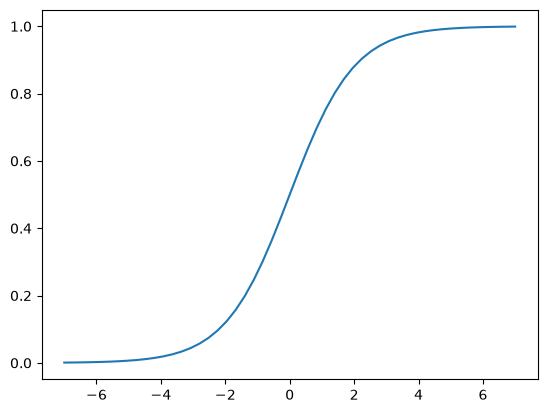

In [73]:
z = np.linspace(-7, 7, 51)
plt.plot(z, sigmoid(z))

The curve has an S shape: scores below roughly -5 give a probability close to 0, scores above roughly 5 give a probability close to 1, and everything in between moves smoothly between the two extremes. A score of 0 means a 50% chance.



In [74]:
def linear_regression(xi):
    result = w0
    
    for j in range(len(w)):
        result = result + xi[j] * w[j]
        
    return result

In [75]:
#Logistic regression needs only one change - 
# pass the score through the sigmoid before returning it:


def logistic_regression(xi):
    score = w0
    
    for j in range(len(w)):
        score = score + xi[j] * w[j]
        
    result = sigmoid(score)
    return result

### Training the model

In [78]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='lbfgs')
# solver='lbfgs' is the default solver in newer version of sklearn
# for older versions, you need to specify it explicitly
model.fit(X_train, y_train)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

The solver is the optimization algorithm that finds the best weights. After fit, the model has learned both parts of the formula from the previous lesson. The bias term w0 is in intercept_:



In [ ]:
print(model.intercept_[0])
print(model.coef_[0].round(3))


NameError: name 'model' is not defined

In [ ]:
y_pred = model.predict_proba(X_val)[:, 1]

predict_proba returns a matrix with two columns: the probability of class 0 and the probability of class 1. The two columns always sum up to 1, so it is enough to take the second one - hence [:, 1].

Now we decide: if the model thinks the probability of churn is 50% or more, we predict that the customer will churn

In [ ]:
churn_decision = (y_pred >= 0.5)

In [ ]:
### Accuracy
(y_val == churn_decision).mean()

#This metric is accuracy: the fraction of predictions the model got right. 
# Here it is 80% - in 80% of the cases, the model predicted churn or no churn correctly.



In [ ]:
# We can also look at it from a dataframe. Let's put the predictions and the actual values side by side:


df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [79]:
df_pred['correct'] = df_pred.prediction == df_pred.actual
df_pred.correct.mean()

#Same number, as expected. Taking the mean of a boolean column counts the fraction of True values, because True is 1 and False is 0.

# An accuracy of 80% is a reasonable start for this problem. The choice of the 0.5 threshold affects this number - we will see how to pick a better threshold when we look at classification metrics in more detail.

NameError: name 'df_pred' is not defined

### Model interpretation
Looking at the coefficient.   
The model we trained has 45 weights, but model.coef_[0] is just an array of numbers - we do not know which weight belongs to which column. Let's pair them up.

In [80]:
# First, a quick reminder of how zip works. It takes two sequences and joins them element by element
a = [1, 2, 3, 4]
b = 'abcd'
dict(zip(a, b))

{1: 'a', 2: 'b', 3: 'c', 4: 'd'}

In [ ]:
# We can do the same with the feature names and the weights:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

Now each weight has a name. The interpretation is the same as in linear regression: a positive weight pushes the score - and therefore the predicted probability - up, a negative weight pushes it down.

Some of what we see matches the feature importance analysis from the beginning of the module. Recall that internetservice=fiber_optic had a high churn risk and contract=month-to-month too - both get clearly positive weights. Customers with contract=two_year almost never churn, and its weight is the most negative one.

Note how the one-hot encoding works here. In the formula, every category of a feature has its own weight, but for any given customer only one of them is multiplied by 1 - all the others are multiplied by 0. So for contract, a month-to-month customer only "uses" the weight 0.475, a two-year customer only the weight -0.408.

The weights of the full model are a bit hard to trust individually - there are many correlated features, and 45 weights is a lot to look at. Let's train a smaller model.



### Interpreting a smaller model

We take three features: contract, tenure and monthlycharges - the ones that looked most important during EDA:



In [ ]:
small = ['contract', 'tenure', 'monthlycharges']

dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [ ]:
#We encode them with a fresh DictVectorizer:

dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

In [ ]:
#This time the vectorizer creates only five columns:
dv_small.get_feature_names_out()

In [ ]:
# Three binary columns for the contract categories, plus the two numerical features. Train the model on this small matrix:

X_train_small = dv_small.transform(dicts_train_small)

model_small = LogisticRegression(solver='lbfgs')
model_small.fit(X_train_small, y_train)

In [ ]:
# And look at what it learned. The bias term:
w0 = model_small.intercept_[0]
w0


In [ ]:
# The weights, paired with their names:

w = model_small.coef_[0]
dict(zip(dv_small.get_feature_names_out(), w.round(3))

Now the picture is much clearer:

Compared to a two-year contract (weight -0.949), being on month-to-month (weight +0.97) pushes churn probability up a lot
Each extra month of tenure slightly decreases it (-0.036 per month)
Monthly charges slightly increase it (+0.027 per dollar)


### Scoring a customer by hand

With five numbers we can compute a prediction manually. Take a customer on a two-year contract, paying $30 per month, with 24 months of tenure. The score is the bias plus the weighted features - only one of the three contract weights applies, because only one of them is 1:



In [81]:
-2.47 + (-0.949) + 30 * 0.027 + 24 * (-0.036)

-3.473

The score is -3.473. To turn it into a probability, apply the sigmoid. In a notebook, the underscore _ refers to the output of the previous cell

Only a 3% chance of churn - exactly what we would expect from a loyal customer on a two-year contract.

Try another one: month-to-month contract, $50 per month, 5 months of tenure. The score is -2.47 + 0.97 + 50 * 0.027 - 5 * 0.036 = -0.33, and the sigmoid of that is about 0.42 - a 42% churn risk.



One useful observation: the sigmoid of 0 is 0.5. So if the score is positive, the customer is more likely to churn than not; if it is negative, less likely. In the example above the score was -0.33, just below the middle.



### Using the model


Final model  
During training and tuning we kept the test set untouched. Now that we no longer need the validation set for checking the model, we can use that data for training too - more data usually means a slightly better model. That is exactly what df_full_train is for:



In [ ]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

y_full_train = df_full_train.churn.values

In [ ]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_full_train, y_full_train)

In [ ]:
#Checking on the test set
dicts_test = df_test[categorical + numerical].to_dict(orient='records')
X_test = dv.transform(dicts_test)

y_pred = model.predict_proba(X_test)[:, 1]
churn_decision = (y_pred >= 0.5)
(churn_decision == y_test).mean()


Scoring one customer


In [ ]:
customer = dicts_test[-1]
customer

In [ ]:
X_small = dv.transform([customer])
model.predict_proba(X_small)[0, 1]

In [ ]:
y_test[-1] # y test value before prediction

This is how the model would be used in a real project. A service receives the customer's data as a dictionary, encodes it with the vectorizer, and asks the model for a probability. If it is above the threshold - for example, 0.5 - the business sends this customer a promotional email with a discount, hoping to keep them.

![Logistic regression Prodction flow](../../images/03-classification-12-using-log-reg-04-production-diagram-imagegen.jpg)